[Bank Marketing Dataset](https://uci-ics-mlr-prod.aws.uci.edu/dataset/222/bank%2Bmarketing)

In [4]:
#import libraries
# import np, pd, sns and plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from google.colab import drive
drive.mount('My_Drive')

Drive already mounted at My_Drive; to attempt to forcibly remount, call drive.mount("My_Drive", force_remount=True).


## Data

The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe (1/0) a term deposit (variable y).

This dataset provides the customer information. It includes 41188 records and 21 fields.

In [6]:
#import banking data and drop nan, visualize the shape and columns list
data = '/content/My_Drive/MyDrive/Ai New Course/bank-additional (1)/bank-additional/bank-additional-full.csv'
df  = pd.read_csv(data,sep=";")
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


#### Input variables

In [8]:
# 2. Data Leakage wale column ko foran udayein

# 3. Data ki shakal aur missing values check karna
print("\n--- Data ki Shape ---")
print(df.shape)

print("\n--- Missing Values Check ---")
# 'unknown' is dataset mein missing value ki tarah hi kaam karta hai
print((df == 'unknown').sum())




# Pehli 5 lines dekhein
df.head()


--- Data ki Shape ---
(41188, 21)

--- Missing Values Check ---
age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


1 - age (numeric)

2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')

3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)

4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')

5 - default: has credit in default? (categorical: 'no','yes','unknown')

6 - housing: has housing loan? (categorical: 'no','yes','unknown')

7 - loan: has personal loan? (categorical: 'no','yes','unknown')

8 - contact: contact communication type (categorical: 'cellular','telephone')

9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')

10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')

11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)

14 - previous: number of contacts performed before this campaign and for this client (numeric)

15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')

16 - emp.var.rate: employment variation rate - (numeric)

17 - cons.price.idx: consumer price index - (numeric)

18 - cons.conf.idx: consumer confidence index - (numeric)

19 - euribor3m: euribor 3 month rate - (numeric)

20 - nr.employed: number of employees - (numeric)

#### Predict variable (desired target):

y - has the client subscribed a term deposit? (binary: '1','0')

The education column of the dataset has many categories and we need to reduce the categories for a better modelling. The education column has the following categories:

/tmp/ipykernel_1947/1064264532.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='education', order=df['education'].value_counts().index, palette='viridis')


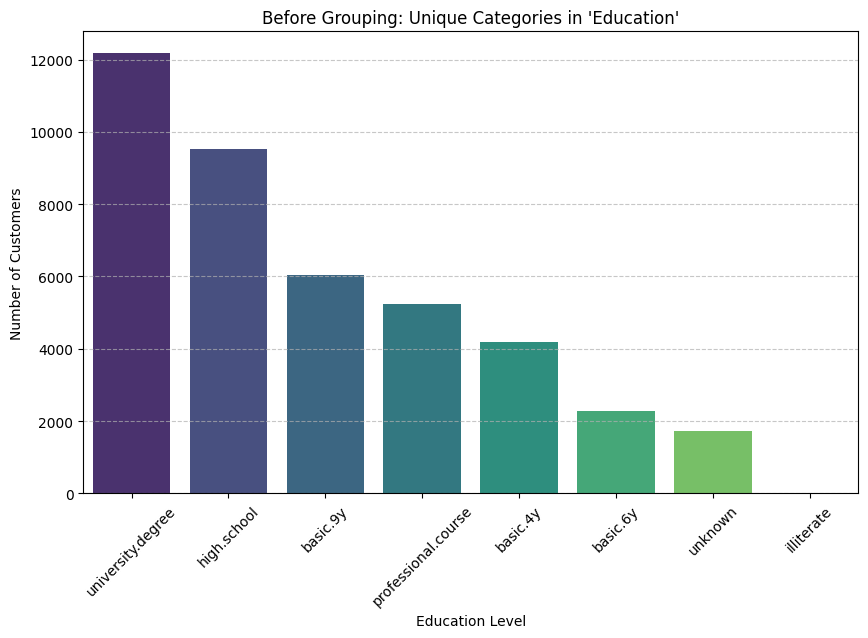


--- Exact Counts ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(10, 6))

# sns.countplot automatically count kar ke bar chart bana dega
# order=... lagane se sab se bari category pehle aayegi aur choti baad mein
sns.countplot(data=df, x='education', order=df['education'].value_counts().index, palette='viridis')

plt.title("Before Grouping: Unique Categories in 'Education'")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45) # Text ko thora tehra (rotate) kiya hai taake aapas mein mix na ho
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Values print kar ke bhi dekh lete hain
print("\n--- Exact Counts ---")
print(df['education'].value_counts())

Let us group "basic.4y", "basic.9y" and "basic.6y" together and call them "basic".

In [10]:
# convert "basic.4y", "basic.9y" and "basic.6y" into "basic" only.
df['education'] = df['education'].replace({'basic.4y': 'basic',
                                           'basic.6y': 'basic',
                                           'basic.9y': 'basic'})


After grouping, this is the columns

In [11]:
# visualize unique values in education col
print("--- Education ki Nayi Categories ---")
print(df['education'].value_counts())

--- Education ki Nayi Categories ---
education
basic                  12513
university.degree      12168
high.school             9515
professional.course     5243
unknown                 1731
illiterate                18
Name: count, dtype: int64


In [12]:
#convert education variable into numerical one
for col in df.columns:
    if df[col].dtype == 'object':
        mode_val = df[df[col] != 'unknown'][col].mode()[0]
        df[col] = df[col].replace('unknown', mode_val)

# 3. Ab in saaf aur grouped categories ko numbers (cat.codes) mein badlein
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

print("\n✅ Grouping aur Encoding dono mukammal ho gaye!")


✅ Grouping aur Encoding dono mukammal ho gaye!


In [13]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,1,0,1,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,1,0,0,1,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,5,1,3,0,1,0,0,7,0,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,1,1,3,0,0,0,0,7,0,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,5,1,4,0,1,0,0,7,0,...,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,9,1,3,0,0,0,0,7,0,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1


### Data exploration

In [14]:
# count the unique values of target variable
print(df['y'].value_counts())

y
0    36548
1     4640
Name: count, dtype: int64


/tmp/ipykernel_1947/1998487312.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', palette='Set1')


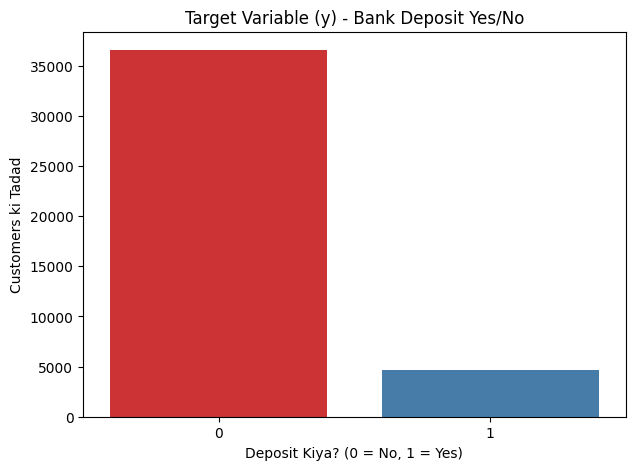

In [15]:
# Countplot shows the counts of observations in each categorical bin using bars, sns.countplot
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Graph ka size set karna
plt.figure(figsize=(7, 5))

# 2. Countplot banana (x='y' ka matlab hai ke Target variable ko graph pe lagao)
sns.countplot(data=df, x='y', palette='Set1')

# 3. Graph ko sajana (Titles aur Labels)
plt.title("Target Variable (y) - Bank Deposit Yes/No")
plt.xlabel("Deposit Kiya? (0 = No, 1 = Yes)")
plt.ylabel("Customers ki Tadad")

# 4. Graph show karna
plt.show()

There are 36548 no's and 4640 yes's in the outcome variables.

### Feature Selection

Phase 3: Feature Selection (Correlation Analysis)...



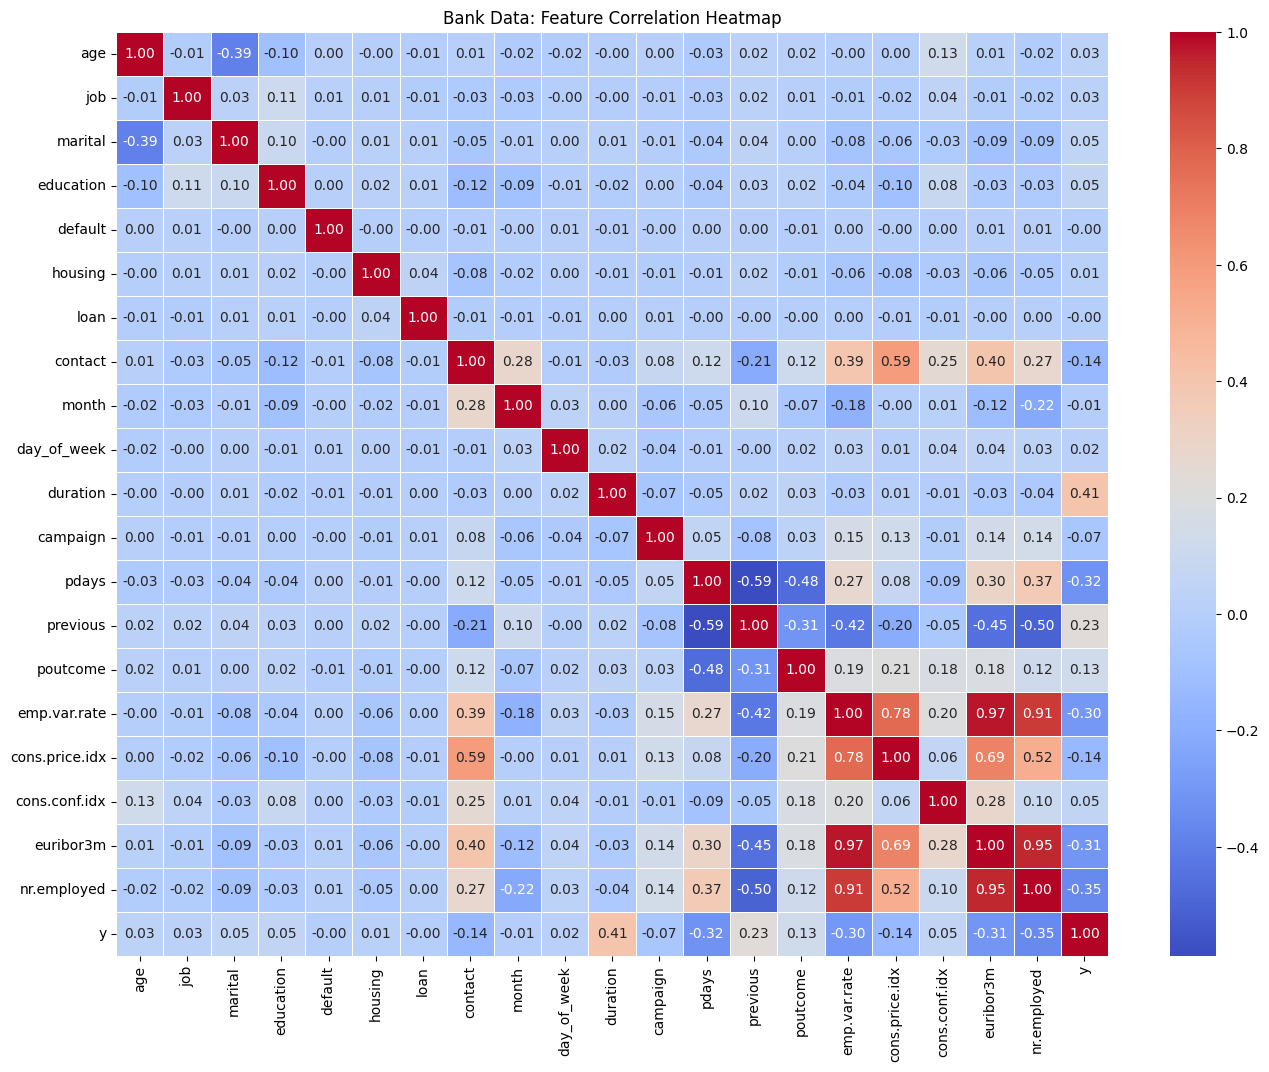


--- Features ka 'Target (y)' ke sath Rishta ---
y                 1.000000
duration          0.405274
previous          0.230181
poutcome          0.129789
cons.conf.idx     0.054878
education         0.053064
marital           0.045849
age               0.030399
job               0.025482
day_of_week       0.015967
housing           0.011085
default          -0.003041
loan             -0.004466
month            -0.006065
campaign         -0.066357
cons.price.idx   -0.136211
contact          -0.144773
emp.var.rate     -0.298334
euribor3m        -0.307771
pdays            -0.324914
nr.employed      -0.354678
Name: y, dtype: float64


In [16]:
from sklearn import datasets
# perform features selection
import matplotlib.pyplot as plt
import seaborn as sns

print("Phase 3: Feature Selection (Correlation Analysis)...\n")

# 1. Correlation Matrix banayein (Har column ka doosre ke sath talluq)
# Chonke data bohat bara hai, hum figure size thora bara rakh rahe hain
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()

# 2. Heatmap draw karein
# fmt=".2f" ka matlab hai point ke baad 2 numbers tak dikhao
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Bank Data: Feature Correlation Heatmap")
plt.show()

# 3. Asli mudday ki baat: Sirf 'y' ke sath sab ka rishta check karein
print("\n--- Features ka 'Target (y)' ke sath Rishta ---")
# Hum values ko sort kar rahe hain taake sab se ahem features oopar aa jayen
target_corr = correlation_matrix['y'].sort_values(ascending=False)
print(target_corr)

In [17]:
# Fuzool columns jinki correlation bilkul zero ke qareeb thi, unhe drop kar rahe hain
columns_to_drop = ['default', 'loan', 'month', 'housing', 'day_of_week']
df = df.drop(columns=columns_to_drop)

print("✅ Noise Removed! Fuzool columns drop ho gaye.")
print("Nayi Data Shape:", df.shape)

✅ Noise Removed! Fuzool columns drop ho gaye.
Nayi Data Shape: (41188, 16)


The features selection helps to improve the prediction of machine learning model



In [18]:
#prepare data frame for taining
from sklearn.model_selection import train_test_split

print("Phase 4: Preparing Data for Training...\n")

# 1. Inputs (X) aur Target (y) ko alag karna
X = df.drop(columns=['y'])  # X mein saare features hain, target nikal diya
y = df['y']                 # y mein sirf target (0 aur 1) hai

# 2. Data ko 80% Training aur 20% Testing mein split karna
# stratify=y hamare imbalanced data ko barabar taqsim karega
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Data Split Mukammal Ho Gaya!")
print(f"X_train (Parhai ka Data): {X_train.shape} - Isme {X_train.shape[0]} customers hain.")
print(f"X_test (Imtehan ka Data): {X_test.shape} - Isme {X_test.shape[0]} customers hain.")

Phase 4: Preparing Data for Training...

✅ Data Split Mukammal Ho Gaya!
X_train (Parhai ka Data): (32950, 15) - Isme 32950 customers hain.
X_test (Imtehan ka Data): (8238, 15) - Isme 8238 customers hain.


### Logistic Regression Model Fitting

#### Predicting the test set results and caculating the accuracy

Phase 6: Random Forest (Jungle) Model Training...

🌟 Random Forest ki Accuracy: 91.78%

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7310
           1       0.69      0.49      0.57       928

    accuracy                           0.92      8238
   macro avg       0.81      0.73      0.76      8238
weighted avg       0.91      0.92      0.91      8238



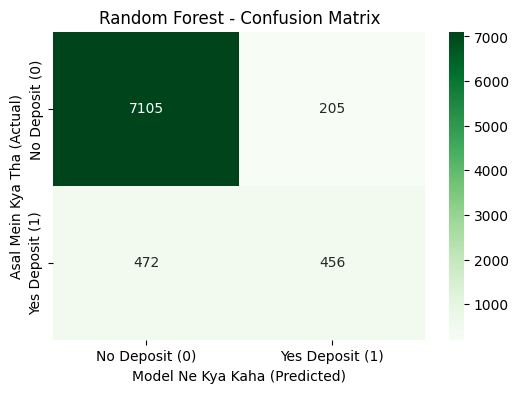

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Phase 6: Random Forest (Jungle) Model Training...\n")

# 1. Model Initialize Karna
# n_estimators=100 ka matlab hai hum 100 Decision Trees ka jungle bana rahe hain
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Model Training (Jungle ab data se seekh raha hai)
# Hum wahi scaled data use kar rahe hain jo humne pehle banaya tha
rf_model.fit(X_train, y_train)

# 3. Prediction (Imtehan ka waqt)
rf_pred = rf_model.predict(X_test)

# 4. Naya Report Card Generate Karna
print(f"🌟 Random Forest ki Accuracy: {accuracy_score(y_test, rf_pred) * 100:.2f}%\n")
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, rf_pred))

# 5. Confusion Matrix (Graph ki shakal mein)
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))
# Is baar hum rang 'Greens' rakh rahe hain taake dono graphs mein farq rahay
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Deposit (0)', 'Yes Deposit (1)'],
            yticklabels=['No Deposit (0)', 'Yes Deposit (1)'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Model Ne Kya Kaha (Predicted)')
plt.ylabel('Asal Mein Kya Tha (Actual)')
plt.show()

In [ ]:
# predict on testdata